In [1]:
from dataset_registery.registery import DatasetManager
from frameworks.LightenDiffusion.models.decom import ImageEncoder, ImageDecoder, RetinexDecomposition
from frameworks.LightenDiffusion.models.LightenDiffusion import Stage1, Stage2, LightenDiffusionPipeline
from frameworks.LightenDiffusion.models.unet import DiffusionUNet
from eda.helpers.data_helpers import split_dataloader
from frameworks.LightenDiffusion.visualization.visualize_stage2 import visualize_stage2_results
from evaluation.lighten_diffusion_stage2 import evaluate_stage2_metrics_avgfirst
import os
import torch
import pandas as pd
from IPython.display import display

%load_ext autoreload
%autoreload 2

/home/grads/o/omarkhater/projects/lle-generative-priors/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_name = "SICE_paired"
dataset_id = "okhater/SICE"
source = "huggingface"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_VISUALIZATION_SAMPLES = 4
print(f"Device used : {device}")

Device used : cuda


In [3]:
registry = DatasetManager()
registry.initialize_dataset(
    name=data_name,
    dataset_id=dataset_id,
    splits=["train", "test"],
    dataset_type="paired",
    hf_cache_dir=f"../../datasets/{data_name}",
)

train_loader = registry.get_dataloader(data_name, "train", batch_size=16, shuffle=True)
test_loader = registry.get_dataloader(data_name, "test", batch_size=16, shuffle=True)
train_loader, val_loader = split_dataloader(train_loader, split_ratio=0.2)

loaders = {
    "train": train_loader, 
    "val": val_loader, 
    "test": test_loader
    }
for name, loader in loaders.items():
    total_samples = len(loader.dataset)
    print(f"Loader: {name}, Total samples: {total_samples}")
    for low_imgs, label in loader:
        print(f"Batch contains {len(low_imgs)} low image samples.")
        print("Low images batch shape:", low_imgs.shape)
        print("Label batch shape:", label.shape)
        break
    print("==="*20)

Loader: train, Total samples: 207
Batch contains 16 low image samples.
Low images batch shape: torch.Size([16, 2, 3, 256, 256])
Label batch shape: torch.Size([16, 3, 256, 256])
Loader: val, Total samples: 51
Batch contains 16 low image samples.
Low images batch shape: torch.Size([16, 2, 3, 256, 256])
Label batch shape: torch.Size([16, 3, 256, 256])
Loader: test, Total samples: 46
Batch contains 16 low image samples.
Low images batch shape: torch.Size([16, 2, 3, 256, 256])
Label batch shape: torch.Size([16, 3, 256, 256])


## Loading Trained Models

In [ ]:
def load_trained_model(weights_path, inital_model, device = torch.device('cuda')):
    if not os.path.exists(weights_path):
        raise FileNotFoundError(f"File not found: {weights_path}")
    model_weights = torch.load(weights_path, map_location=device)
    inital_model.load_state_dict(model_weights)

    
    inital_model.to(device)
    inital_model.eval()
    print(f"Loaded model weights from {weights_path}")
    return inital_model

In [5]:
trained_directory = "/home/grads/o/omarkhater/projects/lle-generative-priors/frameworks/LightenDiffusion/trained_models"
latent_space_dim = 64
stage1_model = Stage1(
        encoder=ImageEncoder(64),
        decoder=ImageDecoder(64),
        decomposer=RetinexDecomposition(),
    )
diffusion_net = DiffusionUNet(
    in_channels=latent_space_dim*2,
    out_channels=latent_space_dim,
    ch=64,
    ch_mult=(1, 2, 3, 4),
    num_res_blocks=2,
    dropout=0.0,
    conditional=True,
    resamp_with_conv=True,
)
stage2_model = Stage2(
    diffusion_unet=diffusion_net,
)
model = LightenDiffusionPipeline(
    stage1=stage1_model,
    stage2=stage2_model
)

initial_models = {
    "stage1": {
        "initalizer": stage1_model,
        "weights_path": os.path.join(trained_directory, "stage1/stage1_beta1.pth")
    },

    "lighten_diffusion": {
        "initalizer": model,
        "weights_path": os.path.join(trained_directory, "stage2/lighten_diffusion_beta1.pth")
    }
}


In [6]:
trained_models = {}
for model_name, model_info in initial_models.items():
    weights_path = model_info["weights_path"]
    inital_model = model_info["initalizer"]
    model = load_trained_model(weights_path, inital_model, device=device)
    trained_models[model_name] = model
    
print("All models loaded successfully.")

Loaded model weights from /home/grads/o/omarkhater/projects/lle-generative-priors/frameworks/LightenDiffusion/trained_models/stage1/stage1_beta1.pth
Loaded model weights from /home/grads/o/omarkhater/projects/lle-generative-priors/frameworks/LightenDiffusion/trained_models/stage2/lighten_diffusion_beta1.pth
All models loaded successfully.


In [7]:
model = trained_models["lighten_diffusion"]

## Approach 1: Averaged Output ("Average-First")
- **Method:**  
  Average the m reconstructions into a single representative image, then compute the metrics on that averaged output.

- **Paired Evaluation (with reference):**  
  - **PSNR:** Compares the averaged reconstruction with the ground truth at the pixel level.
  - **SSIM:** Evaluates structural similarity between the averaged output and the reference.
  - **LPIPS:** Assesses perceptual similarity in deep feature space.
  - **NIQE & PI:** Measure naturalness and combine perceptual quality components.

- **Unpaired Evaluation (no reference):**  
  - **NIQE:** Applied to the averaged reconstruction.
  - **Consistency (Average Pairwise LPIPS):** Computes the average LPIPS distance among the m reconstructions, indicating their internal consistency.

### Quantitive Evaluation

#### Train

In [8]:
metrics_train_AF = evaluate_stage2_metrics_avgfirst(model,train_loader)

Evaluating Stage2 (Average-First):   0%|          | 0/13 [00:00<?, ?it/s]/home/grads/o/omarkhater/projects/lle-generative-priors/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/grads/o/omarkhater/projects/lle-generative-priors/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Evaluating Stage2 (Average-First): 100%|██████████| 13/13 [02:12<00:00, 10.17s/it]


#### Test

In [9]:
metrics_test_AF = evaluate_stage2_metrics_avgfirst(model,test_loader)

Evaluating Stage2 (Average-First): 100%|██████████| 3/3 [00:30<00:00, 10.21s/it]


### Summary 

In [10]:
results_df = pd.DataFrame({
    "train_Average_First": metrics_train_AF,
    "test_Average_First": metrics_test_AF,
})
display(results_df)

,train_Average_First,test_Average_First
psnr,11.018953,10.461386
ssim,0.381127,0.376570
lpips,0.702278,0.685425
niqe,6.799082,6.312446
pi,3.750680,3.498935


## Qualitive Evaluation

#### Train

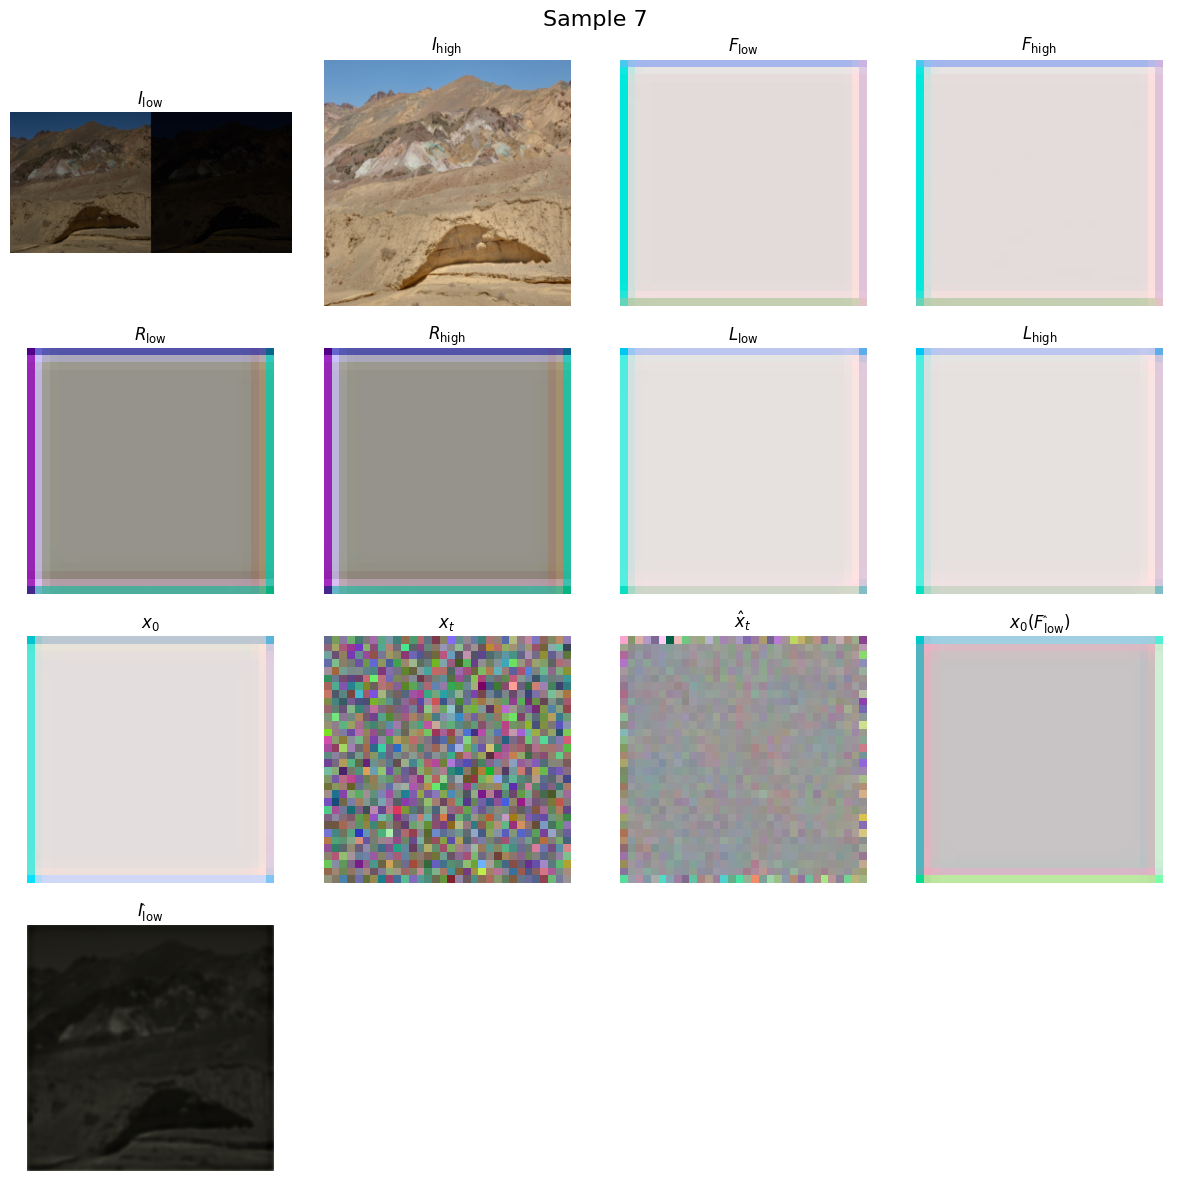

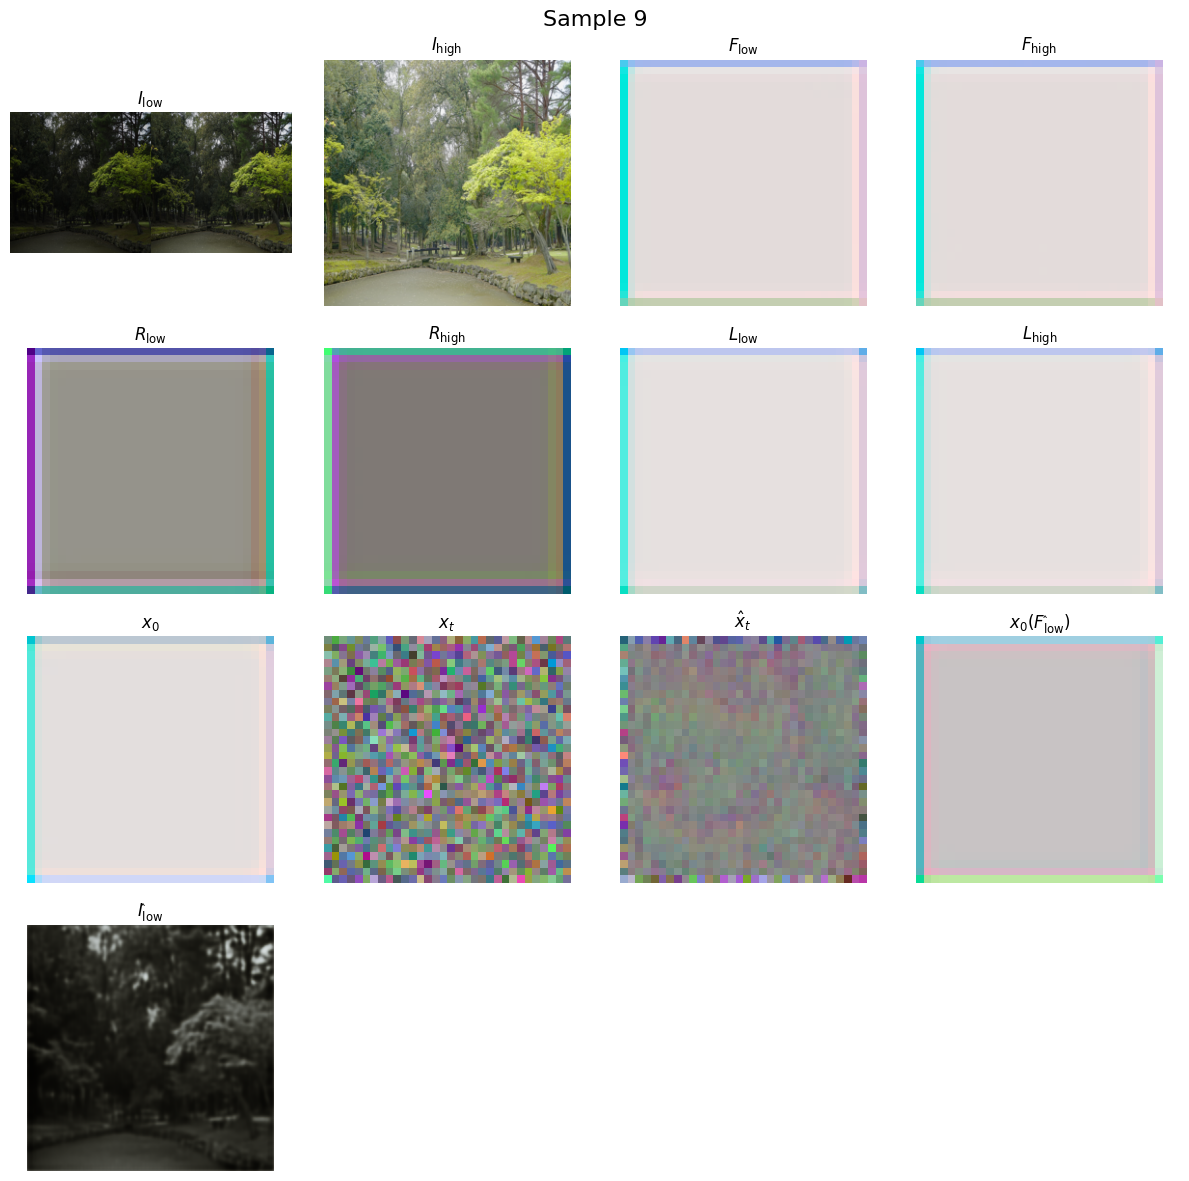

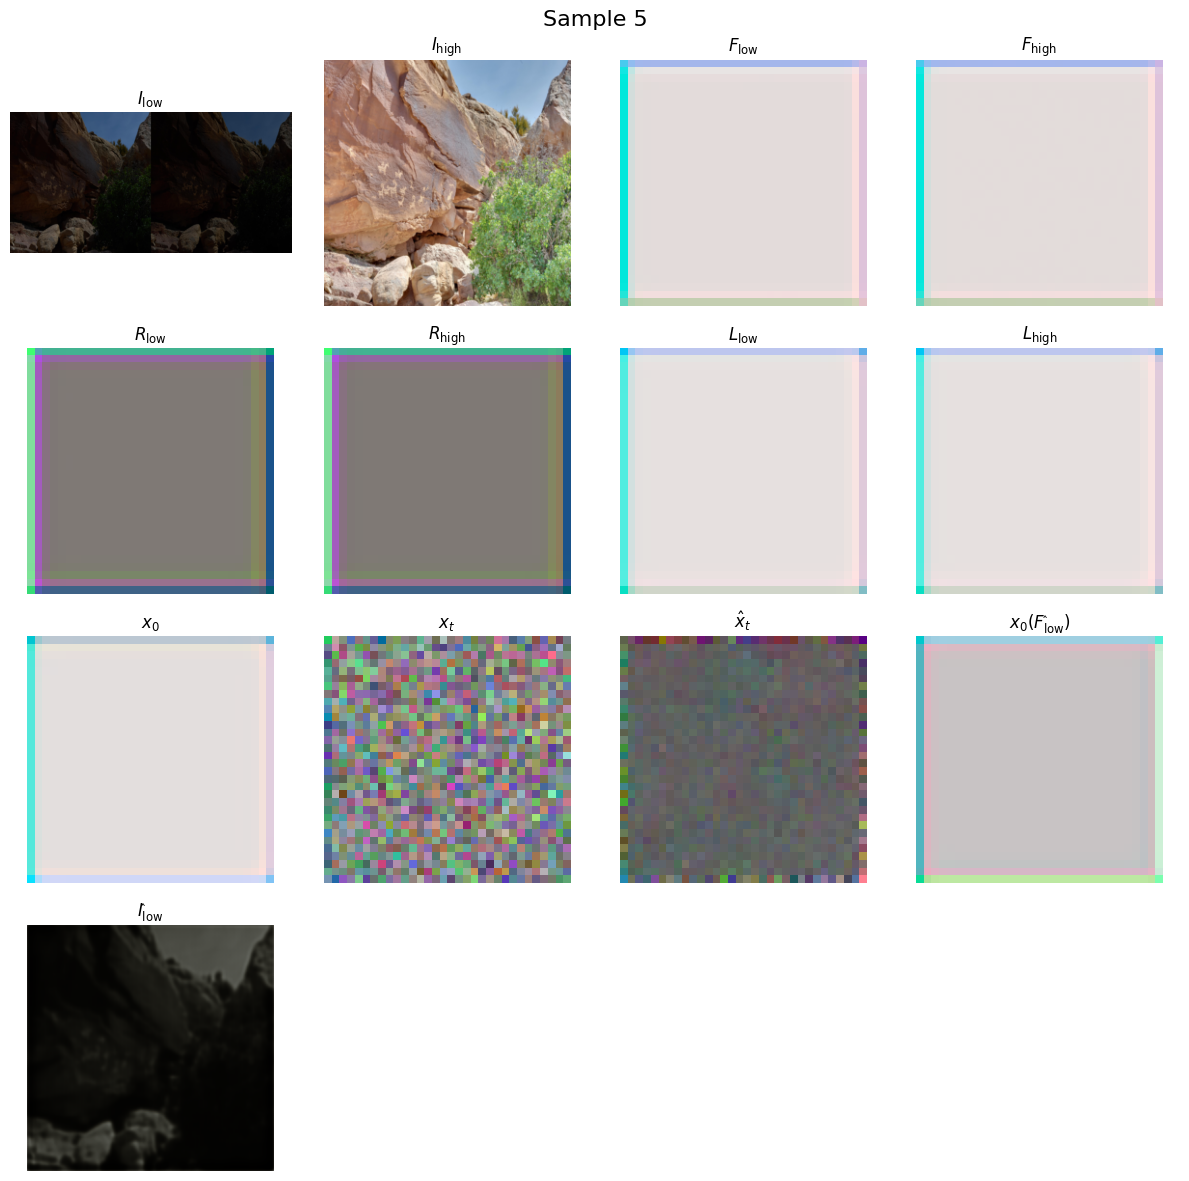

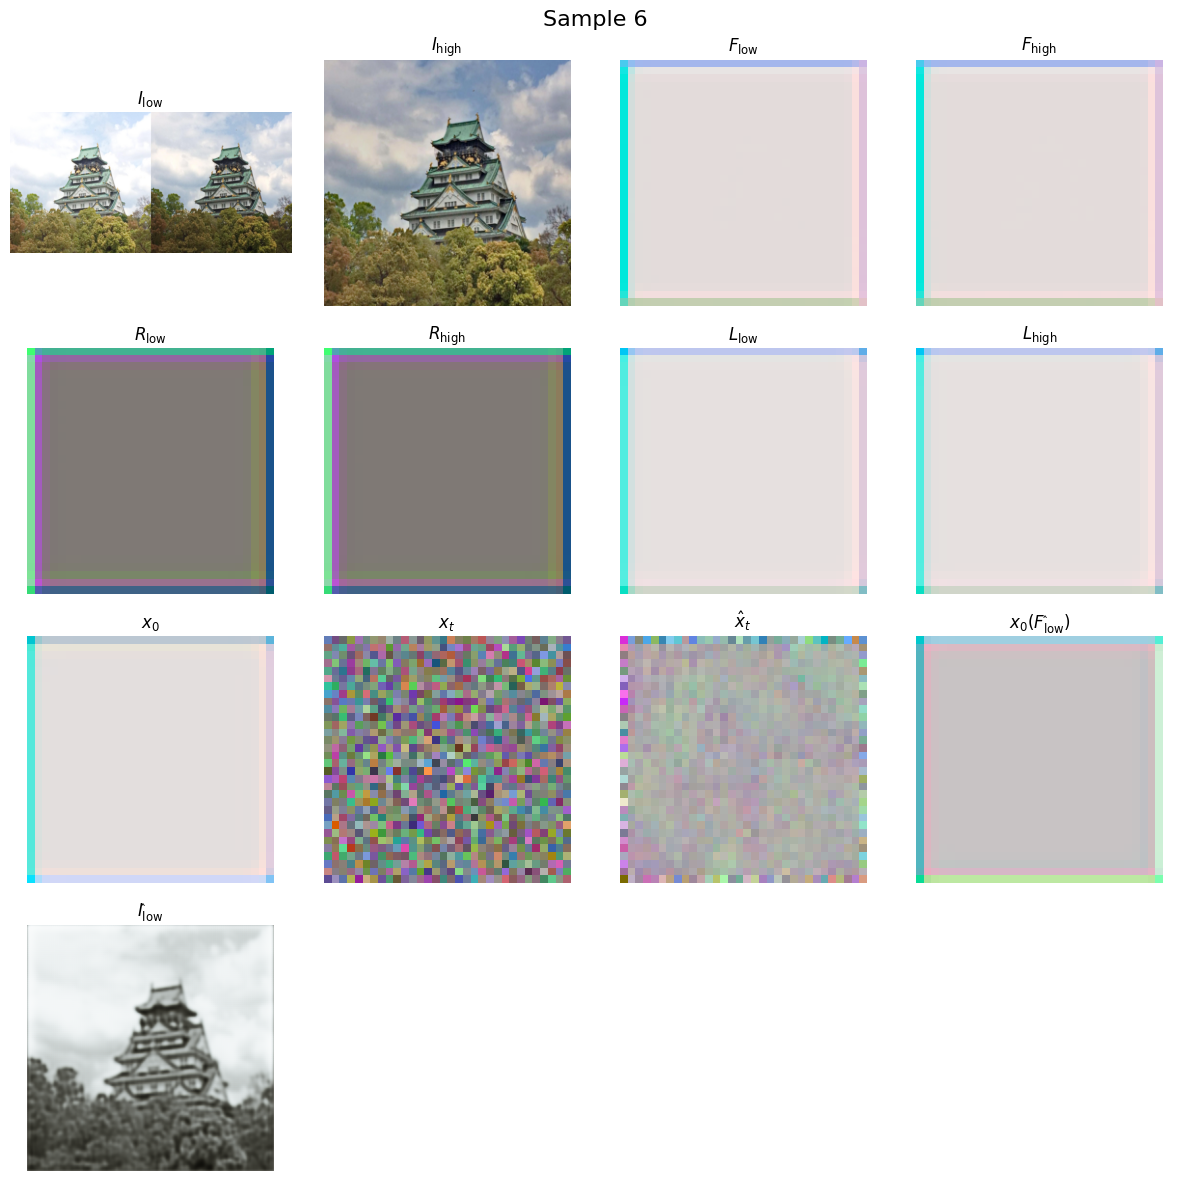

In [11]:
visualize_stage2_results(
    model,
    train_loader,
    num_samples = NUM_VISUALIZATION_SAMPLES
)

#### Test

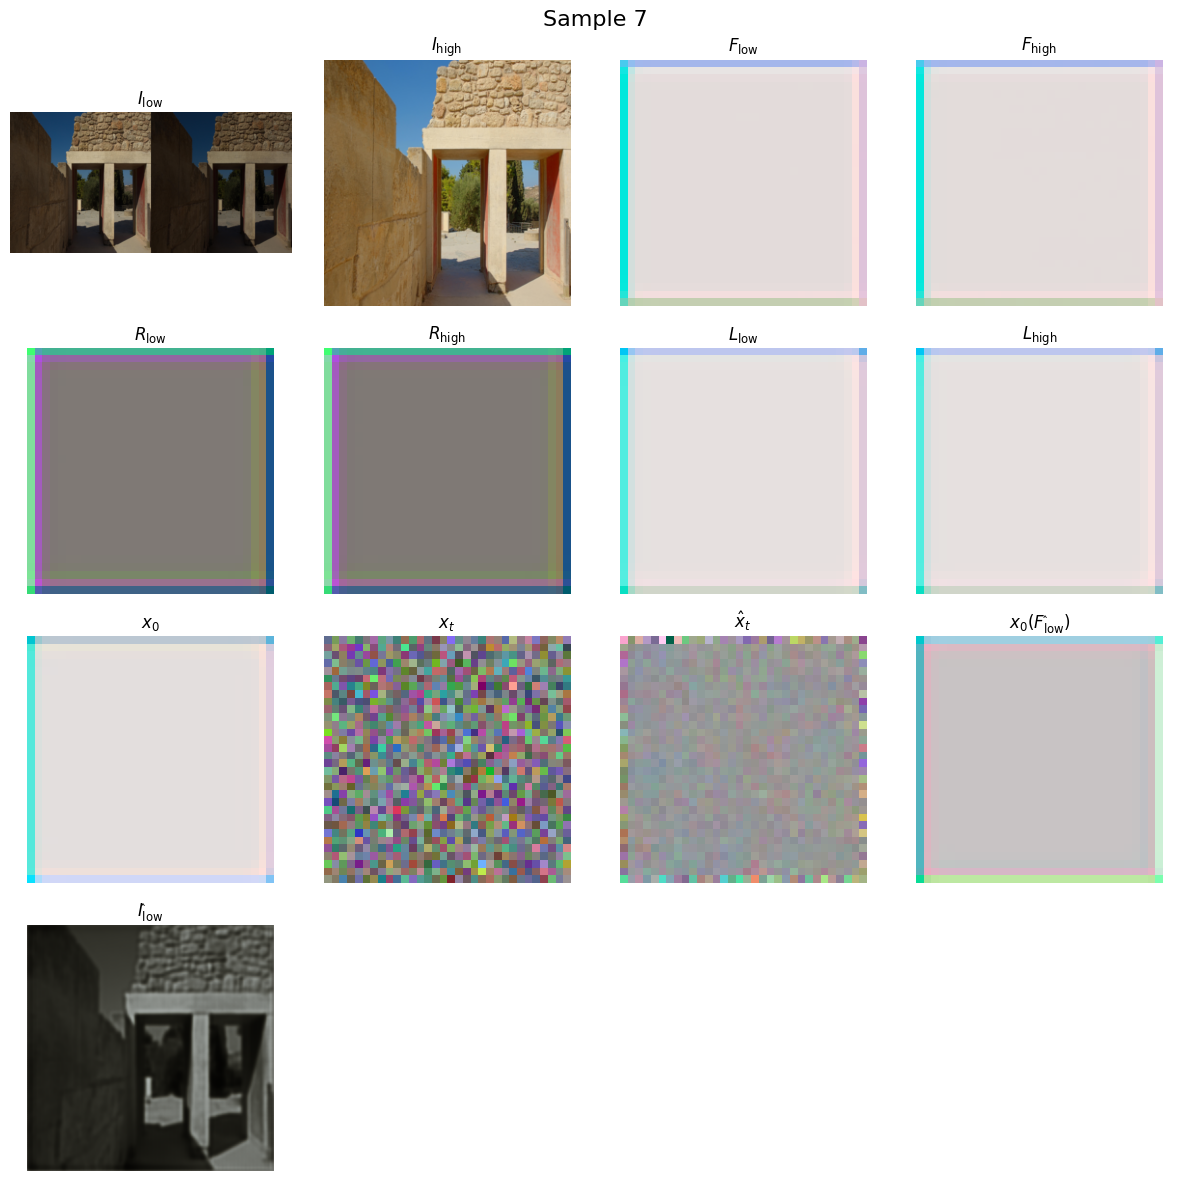

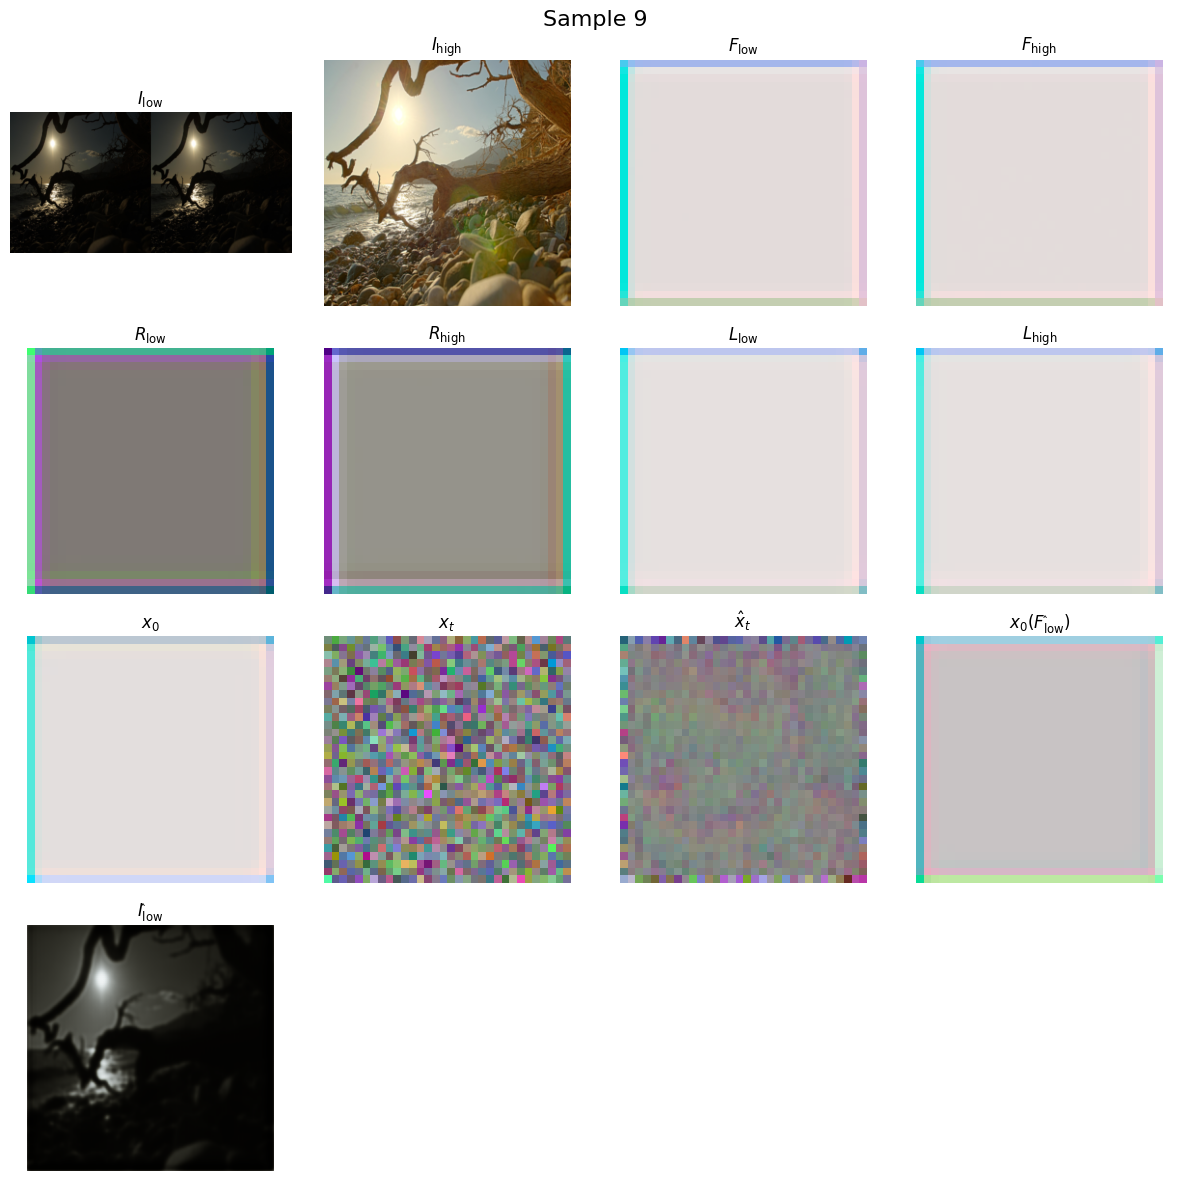

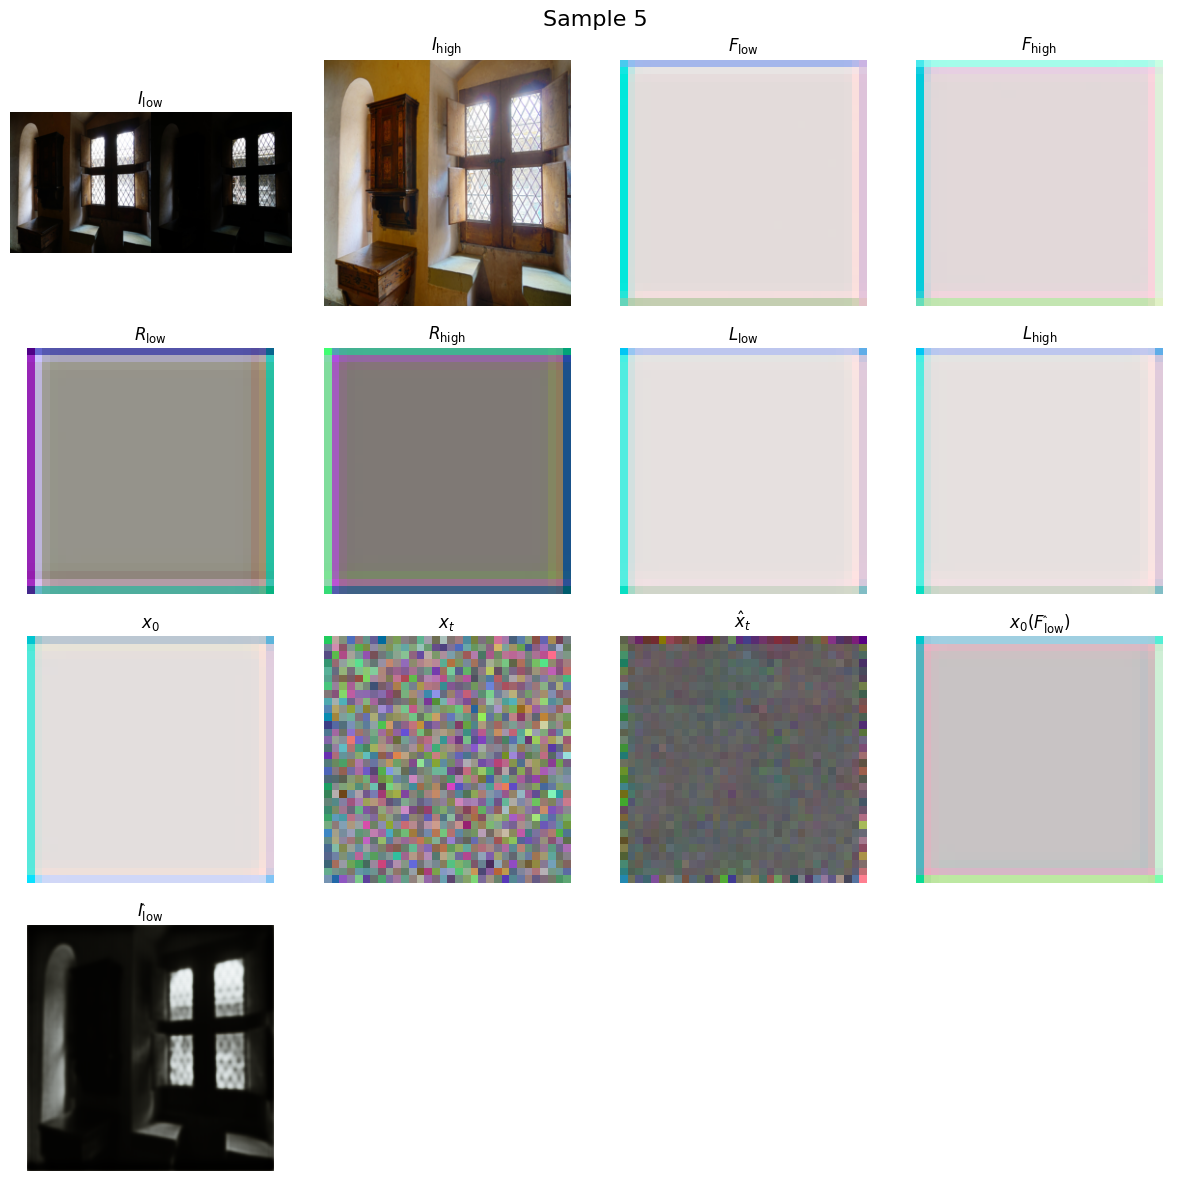

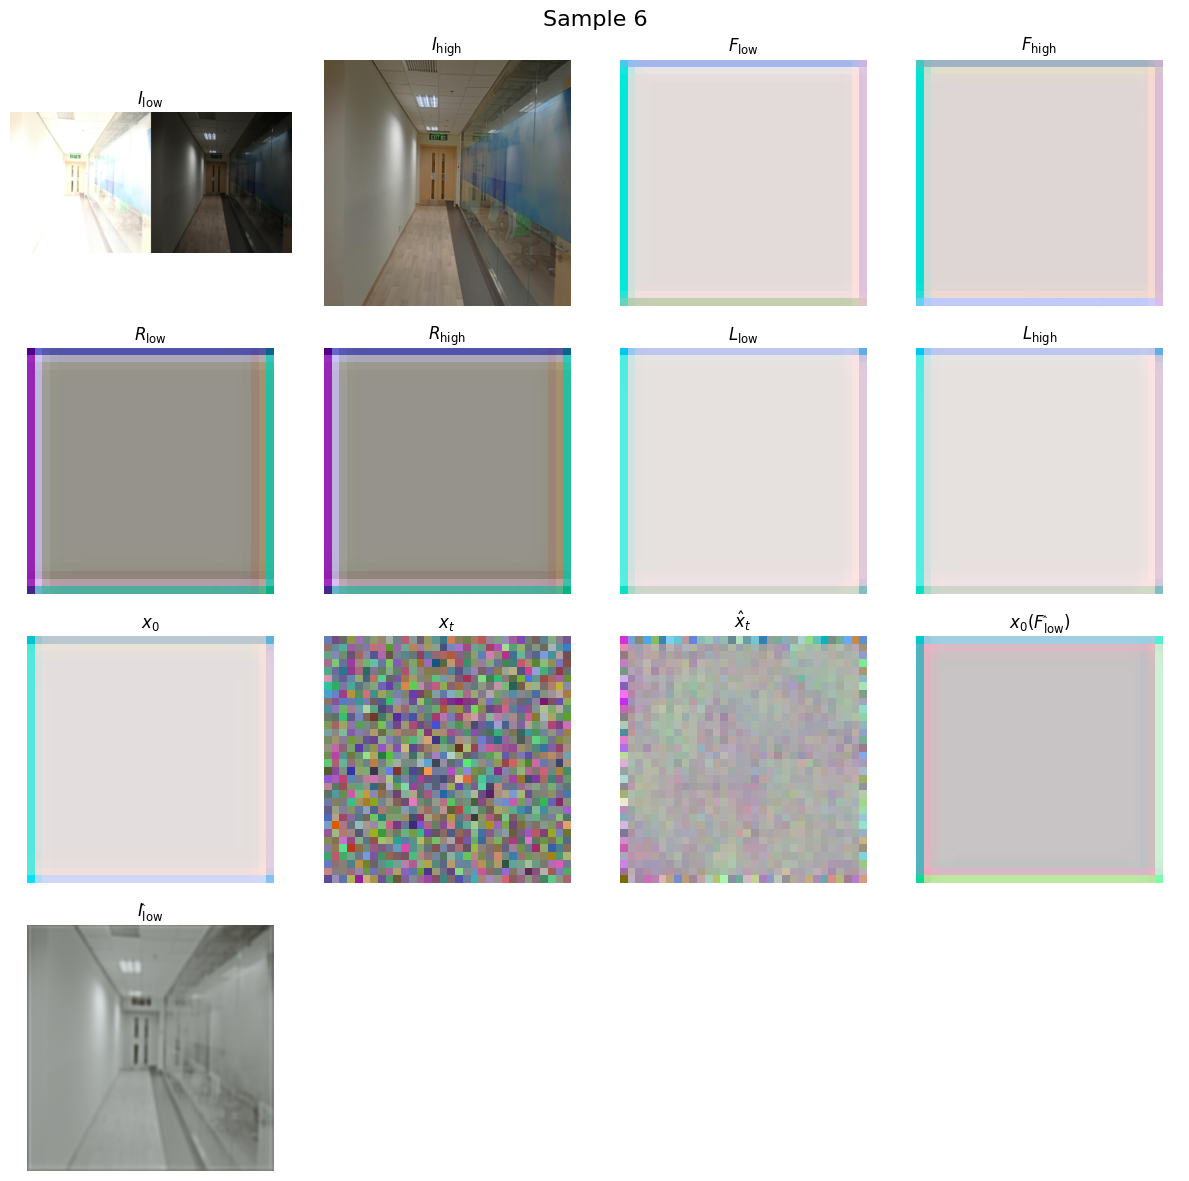

In [12]:
visualize_stage2_results(
    model,
    test_loader,
    num_samples = NUM_VISUALIZATION_SAMPLES,
)